In [1]:
# --- CELL 1: SETUP & IMPORTS ---
# Install the official World Bank API library
!pip install wbgapi 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import wbgapi as wb
import json
import os

# Configure Seaborn for professional-looking EDA plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# --- CELL 2: LIVE DATA INGESTION (BULLETPROOF REAL DATA) ---

print("1. Fetching live vulnerability & economic data from the World Bank API...")
import wbgapi as wb

# The World Bank has different latest years for different metrics (Elevation is ~2010, GDP is ~2022).
# This function fetches the entire history and grabs the most recent non-null value per country.
def get_latest_wb(indicator, col_name):
    df = wb.data.DataFrame(indicator)
    # Forward fill across all years to push the latest valid data to the final column
    latest = df.ffill(axis=1).iloc[:, -1]
    latest.name = col_name
    return latest.reset_index().rename(columns={'economy': 'iso_code'})

# Fetch individually so missing recent years don't overwrite valid historical surveys
elev_df = get_latest_wb('AG.LND.EL5M.ZS', 'Land_Below_5m_Pct')
pop_df  = get_latest_wb('SP.POP.TOTL', 'Population')
gdp_df  = get_latest_wb('NY.GDP.PCAP.CD', 'GDP_Per_Capita')

# Merge the World Bank data safely
wb_df = elev_df.merge(pop_df, on='iso_code').merge(gdp_df, on='iso_code')

# Attach Region and Country Names
regions = wb.economy.DataFrame().reset_index()[['id', 'name', 'region']]
wb_df = pd.merge(wb_df, regions, left_on='iso_code', right_on='id')

print("2. Fetching live CO2 emissions data from Our World In Data (GitHub)...")
owid_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
co2_df = pd.read_csv(owid_url)

# Get the most recent non-null CO2 data for each country dynamically
co2_recent = co2_df.dropna(subset=['iso_code', 'co2_per_capita']).sort_values('year').groupby('iso_code').last().reset_index()
co2_recent = co2_recent[['iso_code', 'co2_per_capita']]

print("3. Merging and cleaning datasets...")
final_df = pd.merge(wb_df, co2_recent, on='iso_code', how='inner')

# Format columns for the EDA graphs
final_df['Population_Millions'] = final_df['Population'] / 1_000_000
final_df['Pop_At_Risk_Millions'] = final_df['Population_Millions'] * (final_df['Land_Below_5m_Pct'] / 100)
final_df.rename(columns={'name': 'Country', 'region': 'Region', 'co2_per_capita': 'Emissions_Per_Capita'}, inplace=True)

# Clean out non-sovereign aggregated regions (like "World" or "Arab World")
df = final_df[final_df['Region'] != ''].copy()
df = df.dropna(subset=['Land_Below_5m_Pct', 'Emissions_Per_Capita', 'GDP_Per_Capita'])

print(f"Success! Loaded {len(df)} real, sovereign nations into the pipeline.")
display(df[['Country', 'Region', 'Land_Below_5m_Pct', 'Emissions_Per_Capita', 'GDP_Per_Capita']].sort_values('Land_Below_5m_Pct', ascending=False).head(10))

1. Fetching live vulnerability & economic data from the World Bank API...
2. Fetching live CO2 emissions data from Our World In Data (GitHub)...
3. Merging and cleaning datasets...
Success! Loaded 202 real, sovereign nations into the pipeline.


,Country,Region,Land_Below_5m_Pct,Emissions_Per_Capita,GDP_Per_Capita
118,Marshall Islands,EAS,81.703422,4.112,7726.336689
116,Maldives,SAS,80.483402,4.369,13379.351358
19,"Bahamas, The",LCN,69.736351,7.650,39455.446655
187,Tuvalu,EAS,68.017131,1.183,6344.775019
97,Kiribati,EAS,67.586212,0.539,2288.634714
176,Turks and Caicos Islands,LCN,63.314476,8.136,37506.779843
135,Netherlands,ECS,52.008458,6.297,67520.421896
112,"Macao SAR, China",EAS,46.879766,1.467,72004.743702
23,Bermuda,NAC,35.964960,8.506,142855.374714
18,Bahrain,MEA,33.805240,24.270,29653.568273


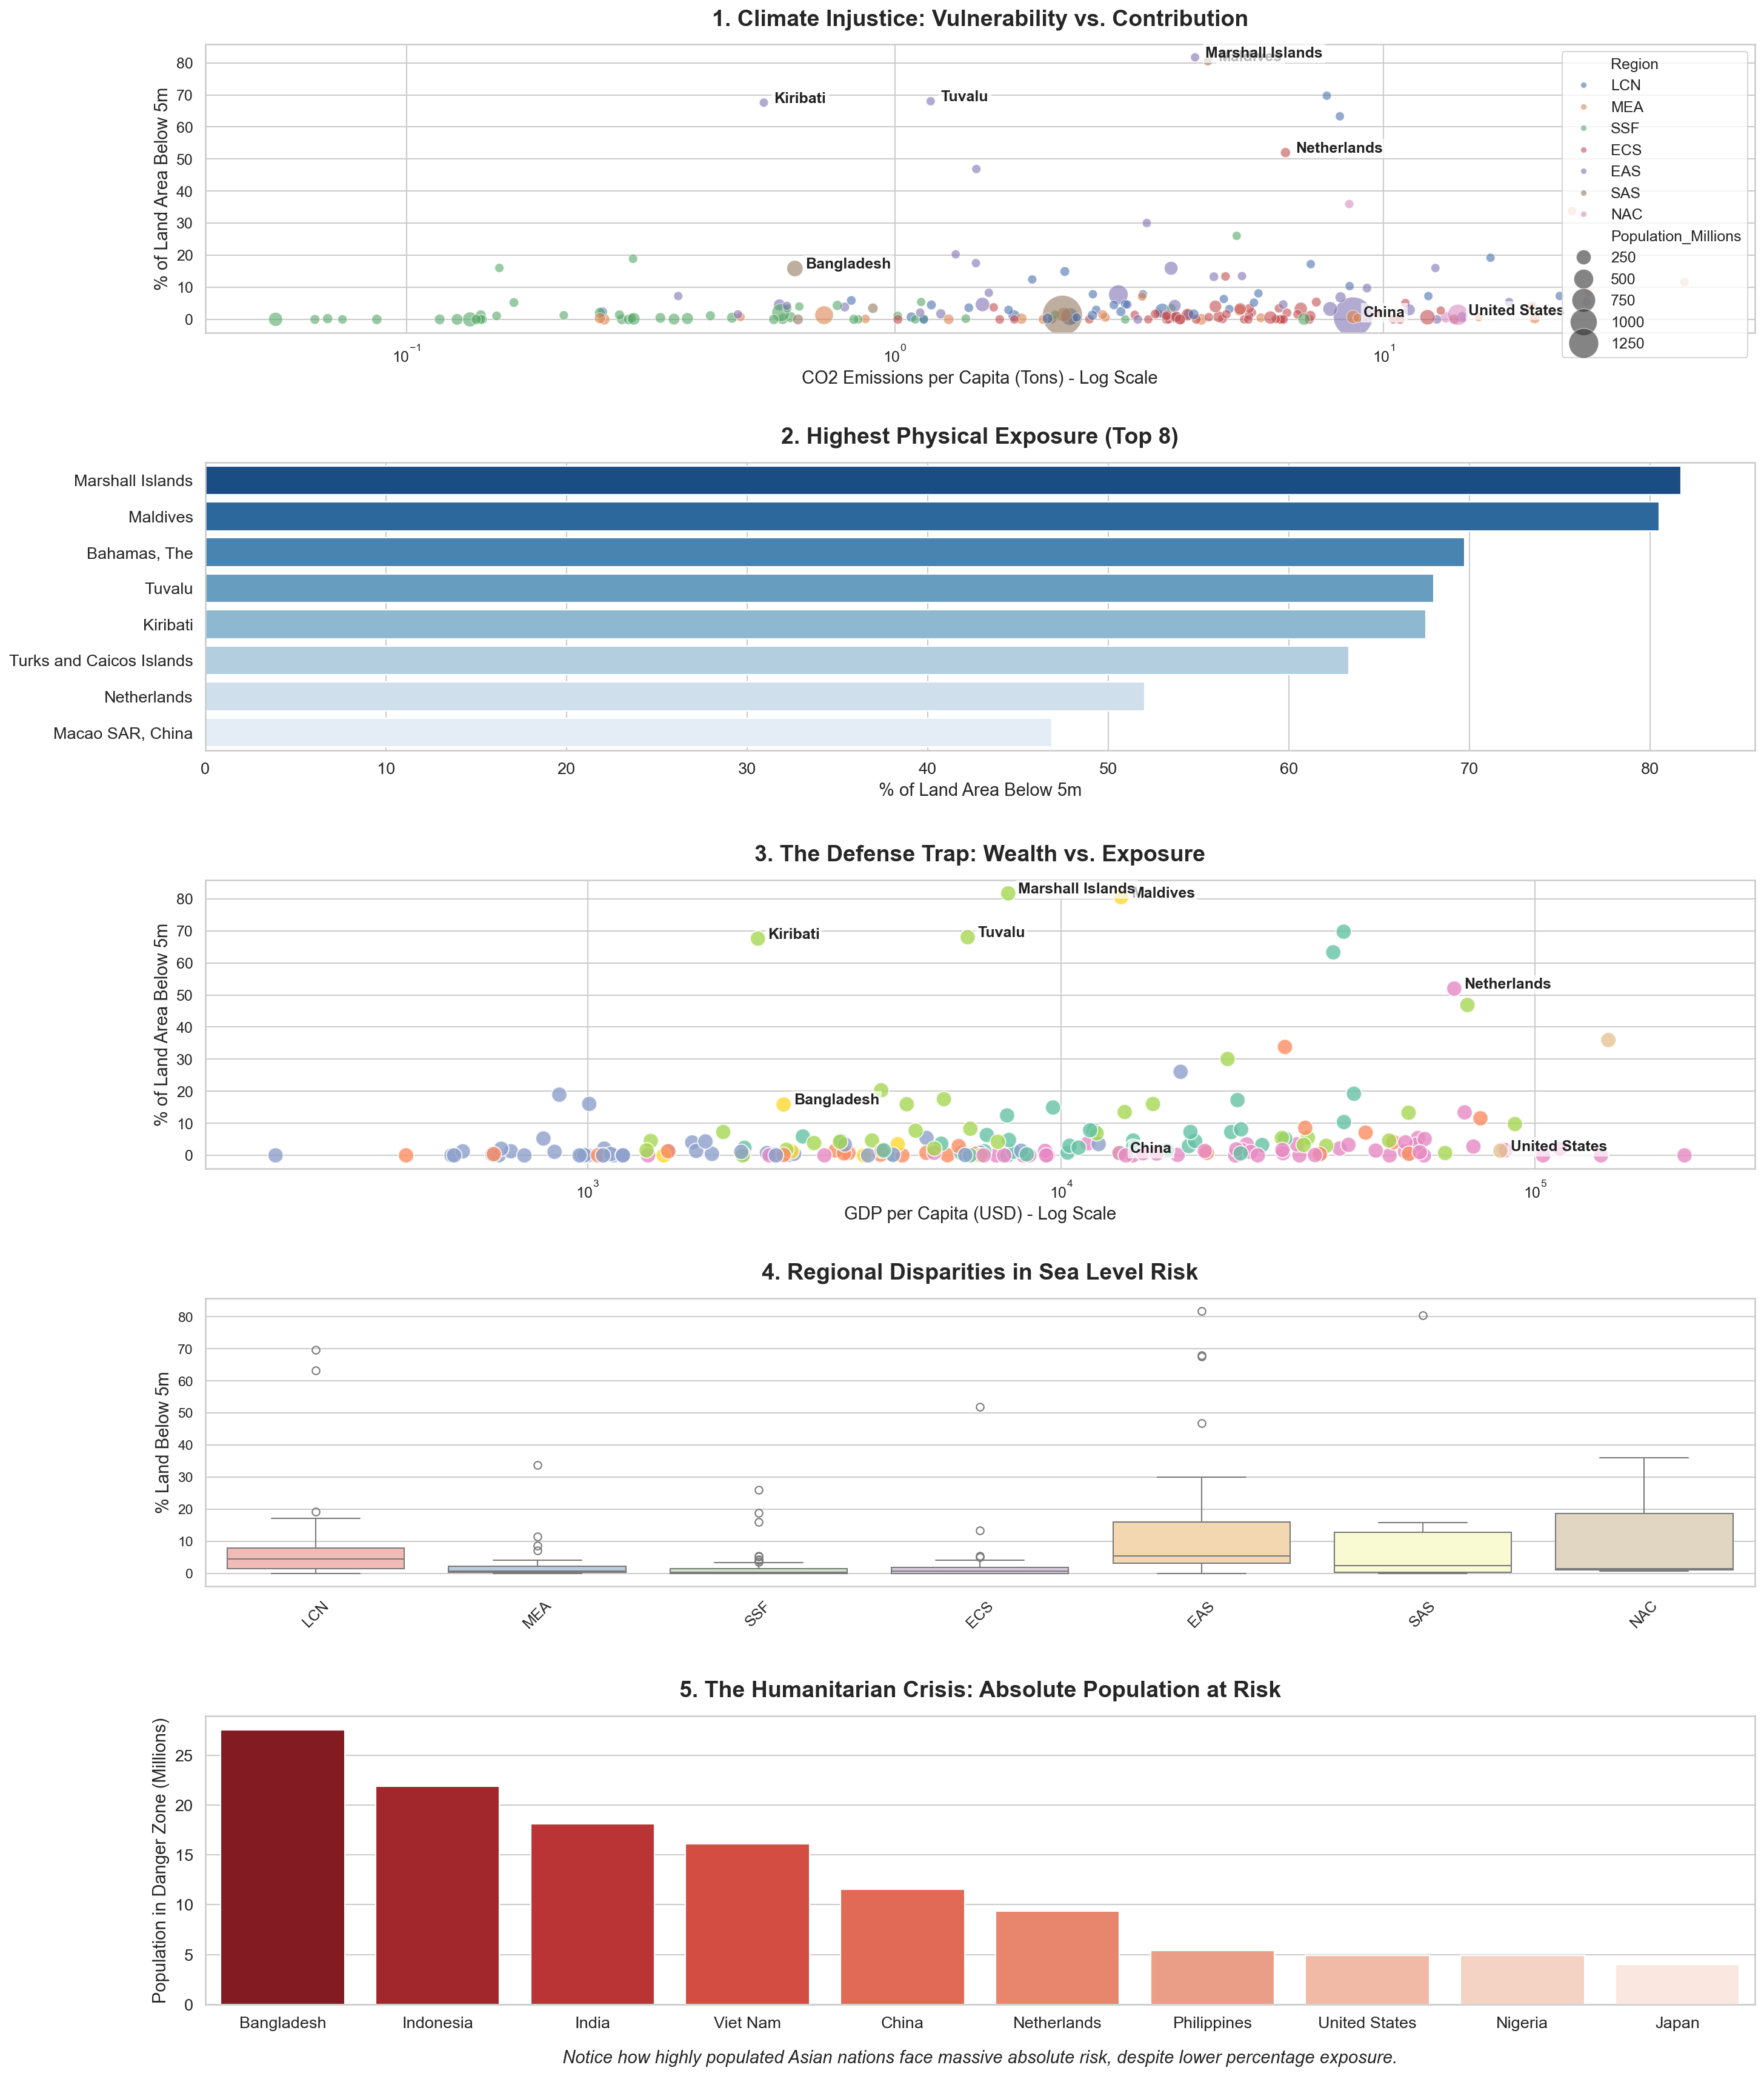

In [3]:
# --- CELL 3: EXPLORATORY DATA ANALYSIS (PRESENTATION SIZED) ---

# FIX 1: Massively increased the canvas size (Width: 22, Height: 28)
fig = plt.figure(figsize=(22, 28))

# FIX 2: Increased height space (hspace) so X-axis labels don't touch the titles below them
plt.subplots_adjust(hspace=0.45, wspace=0.25)

ax1 = plt.subplot(5, 1, 1)
ax2 = plt.subplot(5, 1, 2)
ax3 = plt.subplot(5, 1, 3)
ax4 = plt.subplot(5, 1, 4)
ax5 = plt.subplot(5, 1, 5)

# --- HELPER FUNCTION: Label Key Countries ---
def annotate_key_nations(ax, x_col, y_col):
    key_nations = ['United States', 'China', 'Maldives', 'Tuvalu', 'Netherlands', 'Kiribati', 'Bangladesh', 'Marshall Islands']
    for country in key_nations:
        row = df[df['Country'] == country]
        if not row.empty:
            x_val = row[x_col].values[0]
            y_val = row[y_col].values[0]
            # Increased annotation font size for readability
            ax.text(x_val * 1.05, y_val, country, fontsize=12, weight='bold', color='#222222', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# ---------------------------------------------------------
# 1. Climate Injustice (Scatter)
sns.scatterplot(data=df, x='Emissions_Per_Capita', y='Land_Below_5m_Pct', 
                size='Population_Millions', sizes=(50, 1000), hue='Region', alpha=0.6, ax=ax1)
ax1.set_title('1. Climate Injustice: Vulnerability vs. Contribution', fontsize=18, weight='bold', pad=15)
ax1.set_xlabel('CO2 Emissions per Capita (Tons) - Log Scale', fontsize=14)
ax1.set_ylabel('% of Land Area Below 5m', fontsize=14)
ax1.set_xscale('log') 
ax1.legend(loc='upper right', fontsize=12, markerscale=0.8)
ax1.tick_params(labelsize=12)
annotate_key_nations(ax1, 'Emissions_Per_Capita', 'Land_Below_5m_Pct')

# 2. Highest Physical Exposure (Horizontal Bar)
top_vuln = df.sort_values('Land_Below_5m_Pct', ascending=False).head(8)
sns.barplot(data=top_vuln, x='Land_Below_5m_Pct', y='Country', hue='Country', palette='Blues_r', ax=ax2, legend=False)
ax2.set_title('2. Highest Physical Exposure (Top 8)', fontsize=18, weight='bold', pad=15)
ax2.set_xlabel('% of Land Area Below 5m', fontsize=14)
ax2.set_ylabel('')
ax2.tick_params(labelsize=13)

# 3. Economic Defense Trap (Scatter)
sns.scatterplot(data=df, x='GDP_Per_Capita', y='Land_Below_5m_Pct', 
                hue='Region', s=150, palette='Set2', alpha=0.8, ax=ax3, legend=False)
ax3.set_title('3. The Defense Trap: Wealth vs. Exposure', fontsize=18, weight='bold', pad=15)
ax3.set_xlabel('GDP per Capita (USD) - Log Scale', fontsize=14)
ax3.set_ylabel('% of Land Area Below 5m', fontsize=14)
ax3.set_xscale('log') 
ax3.tick_params(labelsize=12)
annotate_key_nations(ax3, 'GDP_Per_Capita', 'Land_Below_5m_Pct')

# 4. Regional Risk (Boxplot)
sns.boxplot(data=df, x='Region', y='Land_Below_5m_Pct', hue='Region', palette='Pastel1', ax=ax4, legend=False)
ax4.set_title('4. Regional Disparities in Sea Level Risk', fontsize=18, weight='bold', pad=15)
ax4.set_ylabel('% Land Below 5m', fontsize=14)
ax4.tick_params(axis='x', rotation=45, labelsize=12)
ax4.set_xlabel('')

# 5. Absolute Human Impact (Bar) - Stretching across the bottom
top_pop = df.sort_values('Pop_At_Risk_Millions', ascending=False).head(10)
sns.barplot(data=top_pop, x='Country', y='Pop_At_Risk_Millions', hue='Country', palette='Reds_r', ax=ax5, legend=False)
ax5.set_title('5. The Humanitarian Crisis: Absolute Population at Risk', fontsize=18, weight='bold', pad=15)
ax5.set_ylabel('Population in Danger Zone (Millions)', fontsize=14)
ax5.set_xlabel('Notice how highly populated Asian nations face massive absolute risk, despite lower percentage exposure.', fontsize=14, style='italic', labelpad=15)
ax5.tick_params(labelsize=13)

plt.show()